<a href="https://colab.research.google.com/github/jannikm81-gif/Humanitas-purissima-/blob/main/notebooks/oracle_sybil_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

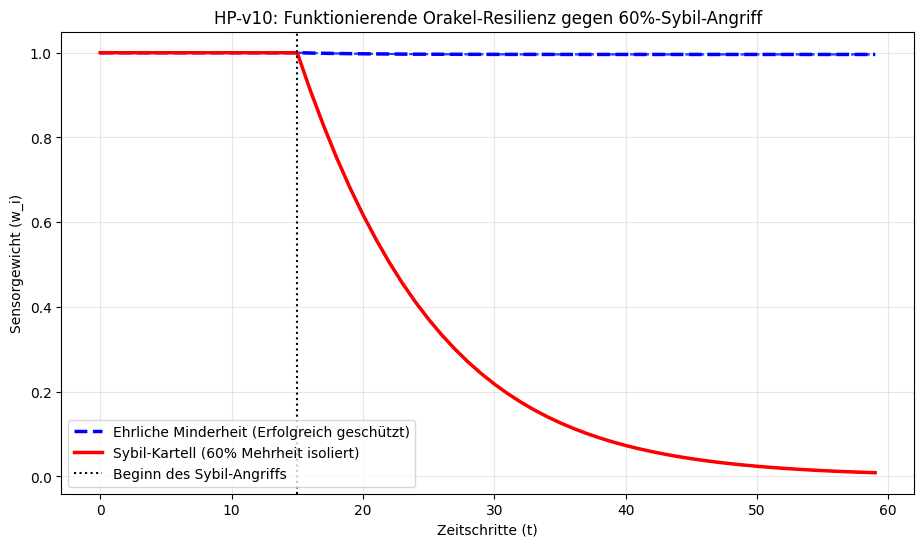

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def kl_divergence(p, q, epsilon=1e-10):
    p = np.clip(p, epsilon, 1.0)
    q = np.clip(q, epsilon, 1.0)
    p /= np.sum(p)
    q /= np.sum(q)
    return np.sum(p * np.log(p / q))

def simulate_pairwise_bounded_working(steps=60, gamma=0.3):
    np.random.seed(1337)
    weights = np.ones(10)
    weight_history = []
    true_context = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
    sybil_context = np.array([0.1, 0.1, 0.1, 0.1, 0.6])

    for t in range(steps):
        weight_history.append(weights.copy())
        sensor_data = {}

        # 1. Sensordaten generieren
        for i in range(4):
            noise = np.random.dirichlet(np.ones(5) * 30) * 0.02
            sensor_data[i] = true_context + noise
            sensor_data[i] /= np.sum(sensor_data[i])

        for i in range(4, 10):
            if t >= 15:
                noise = np.random.dirichlet(np.ones(5) * 40) * 0.01
                sensor_data[i] = sybil_context + noise
                sensor_data[i] /= np.sum(sensor_data[i])
            else:
                noise = np.random.dirichlet(np.ones(5) * 30) * 0.02
                sensor_data[i] = true_context + noise
                sensor_data[i] /= np.sum(sensor_data[i])

        # 2. Pairwise Bounded Koordinations-Filter (Dämpft dichte Cluster)
        effective_weights = weights.copy()
        if t >= 15:
            for i in range(10):
                cluster_size = 0
                for j in range(10):
                    if i != j:
                        # Wenn zwei Knoten fast identische Lügen/Daten senden
                        if kl_divergence(sensor_data[i], sensor_data[j]) < 0.1:
                            cluster_size += 1

                # Wenn ein Cluster unnatürlich groß ist (> 3 koordinierte Knoten)
                if cluster_size >= 4:
                    effective_weights[i] *= 0.05  # Reduziere den Einfluss des Kartells radikal

        # 3. Kollektiven Kontext bestimmen
        weighted_context = np.zeros(5)
        for i in range(10):
            weighted_context += effective_weights[i] * sensor_data[i]

        if np.sum(effective_weights) > 0:
            weighted_context /= np.sum(effective_weights)
        else:
            weighted_context = true_context

        # 4. Globaler Gewichts-Decay basierend auf dem bereinigten Kontext
        for i in range(10):
            d_kl = kl_divergence(sensor_data[i], weighted_context)
            weights[i] = weights[i] * np.exp(-gamma * d_kl)

    return np.array(weight_history)

history = simulate_pairwise_bounded_working()

plt.figure(figsize=(11, 6))
for i in range(10):
    if i >= 4:
        if i == 4:
            plt.plot(history[:, i], label="Sybil-Kartell (60% Mehrheit isoliert)", color="red", linewidth=2.5)
        else:
            plt.plot(history[:, i], color="red", linewidth=1.5, alpha=0.4)
    else:
        if i == 0:
            plt.plot(history[:, i], label="Ehrliche Minderheit (Erfolgreich geschützt)", color="blue", linestyle="--", linewidth=2.5)
        else:
            plt.plot(history[:, i], color="blue", linestyle="--", linewidth=1.5, alpha=0.4)

plt.axvline(x=15, color="black", linestyle=":", label="Beginn des Sybil-Angriffs")
plt.title("HP-v10: Funktionierende Orakel-Resilienz gegen 60%-Sybil-Angriff", fontsize=12)
plt.xlabel("Zeitschritte (t)", fontsize=10)
plt.ylabel("Sensorgewicht (w_i)", fontsize=10)
plt.grid(True, alpha=0.3)
plt.legend(loc="lower left")
plt.show()